# Differentiable normalization of almost-linear lambda terms

Linear lambda terms are rooted trivalent maps over one generator — that is
Zeilberger's isomorphism, implemented by `closed.TermBase.to_map`. The
*almost-linear* fragment, where variables may be copied, encodes as rooted
maps with **two generators**: gamma (trivalent — abstraction `λ` and
application `@`) and delta (arbitrary arity — one node per copied variable
with one port per occurrence).

The geometry of interaction interprets such a map as a **token machine**
(Danos–Régnier, Mackie): a query travels from the root into the term carrying
two stacks — a *multiplicative* (gamma) stack recording the path through
`@`/`λ` nodes, and an *exponential* (delta) stack recording which copy of
each shared subterm it is in. Crossing a node through an auxiliary port
*pushes* a symbol on the corresponding stack; crossing through the principal
port *pops* one and routes accordingly. The principal ports are the function
port of `@`, the root port of `λ` and the binder port of `δ`, so that a beta
redex is a principal–principal cut.

This notebook relaxes the token machine into a neural network:

* stack symbols become $d$-dimensional vectors and stacks become
  fixed-capacity differentiable stacks — each wire of the map carries a
  **pair of sequences**, typed `Dim(Seq(d), Seq(d))`,
* routing becomes a softmax, so message passing (`CMap.pass_messages`,
  the execution formula) is differentiable end to end,
* one shared torch module drives all gamma nodes, one all delta nodes,
  and each *constant* gets its own module — its weights are the unknown.

Böhm-tree readback becomes decoding: a **root network** encodes the address
of a hole in a partially built Böhm tree on the gamma stack, message passing
returns the answer, and a readout classifies it into a Böhm-tree node — one
node per query, so decoding time is proportional to the depth of the normal
form and the loop halts iff the term normalizes. Ground truth comes from
syntactic head reduction, `closed.BohmTree`.

In [1]:
import random
import torch
from discopy.closed import (
    Abstraction, BohmTree, Unitype, Variable)
from discopy.neural import CMap, Dim, Network, Seq

torch.manual_seed(42)
D, L = 8, 16  # vector dimension and stack capacity
o = Unitype()

## Terms, maps and Böhm trees

Church numerals with addition and multiplication are almost-linear: with the
unitype `o`, which is its own exponential, they typecheck even though they
are not simply typed. Copying `f` in a numeral goes to one delta node with
one port per occurrence.

In [2]:
def church(n):
    def body(f):
        def inner(x):
            result = x
            for _ in range(n):
                result = f(result)
            return result
        return o(inner)
    return o(body)


add = o(lambda m: o(lambda n: o(lambda f: o(lambda x: m(f)(n(f)(x))))))
mult = o(lambda m: o(lambda n: o(lambda f: m(n(f)))))

sorted(box.name for box in church(3).to_map().boxes)

['@', '@', '@', 'δ', 'λ', 'λ']

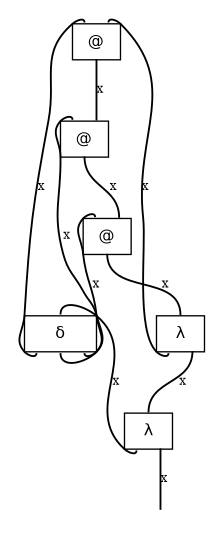

In [3]:
church(3).to_map().draw()

In [4]:
two, three = church(2), church(3)
assert BohmTree.from_term(add(two)(three)) == BohmTree.from_term(church(5))
assert BohmTree.from_term(mult(two)(three)) == BohmTree.from_term(church(6))

partial = BohmTree.from_term(mult(two)(three), budget=5)
partial  # the nodes not reached within the budget are holes

BohmTree(cod=closed.Unitype(cat.Ob('o')), variables=(closed.Variable('f', closed.Unitype(cat.Ob('o'))), closed.Variable('x', closed.Unitype(cat.Ob('o')))), head=0, args=(BohmTree(cod=closed.Unitype(cat.Ob('o')), variables=(), head=0, args=(BohmTree(cod=closed.Unitype(cat.Ob('o')), variables=(), head=0, args=(None,)),)),))

## The three shared networks

Differentiable stacks are `(Q, L, D)` tensors — `Q` parallel queries, depth
`L`, vectors of dimension `D`. Pushing shifts the rows down, popping reads
the top row and shifts up.

* **`GammaCore`** is shared by all `@` and `λ` boxes: it pops and pushes on
  the *gamma* stacks only — a token entering through an auxiliary port gets
  a `(kind, aux)` tag pushed, a token entering through the principal port
  has its head popped and soft-routed to the auxiliaries — while the delta
  stacks ride through untouched, scaled by the routing weights.
* **`DeltaCore`** is the exact dual, on the *delta* stacks, and must work
  for **any arity** with one set of weights: routing is attention over a
  table of index embeddings, so a delta with $n$ ports scores the popped
  head against the first $n$ indices.
* Each **constant** gets its own module answering queries on its single
  wire, with hidden width proportional to the number of generators in its
  type — the unknown value lives in these weights.
* The **root network** turns hole addresses into queries and classifies
  the answers into Böhm-tree nodes ``(binders, head, arity)``.

In [5]:
def push(stack, head):
    return torch.cat([head.unsqueeze(-2), stack[..., :-1, :]], dim=-2)


def pop(stack):
    zero = torch.zeros_like(stack[..., :1, :])
    return stack[..., 0, :], torch.cat([stack[..., 1:, :], zero], dim=-2)


def zeros(q=1):
    return torch.zeros(q, L, D)


class GammaCore(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.tags = torch.nn.Embedding(4, D)
        self.routers = torch.nn.ModuleList(
            [torch.nn.Linear(D, 2) for _ in range(2)])
        self.pop_transform = torch.nn.Linear(D, D)
        self.push_transform = torch.nn.Linear(D, D)


class DeltaCore(torch.nn.Module):
    def __init__(self, max_arity=8):
        super().__init__()
        self.tags = torch.nn.Embedding(max_arity, D)
        self.query = torch.nn.Linear(D, D)
        self.pop_transform = torch.nn.Linear(D, D)
        self.push_transform = torch.nn.Linear(D, D)

In [6]:
class GammaBox(torch.nn.Module):
    """One @ or λ box: wires (principal, aux0, aux1), kind 0 for @, 1 for λ.

    The box takes and returns one message per port in logical order, with
    wire w carried by the gamma port 2w and the delta port 2w + 1."""
    def __init__(self, core, kind, principal, auxes):
        super().__init__()
        self.core, self.kind = core, kind
        self.principal, self.auxes = principal, auxes

    def forward(self, *messages):
        def wire(w):
            return messages[2 * w], messages[2 * w + 1]

        q = next((m.shape[0] for m in messages if m is not None), 1)
        out = [None] * len(messages)
        g_p, d_p = wire(self.principal)
        if g_p is not None:  # pop the gamma head and route
            head, tail = pop(g_p)
            weights = torch.softmax(
                self.core.routers[self.kind](head), dim=-1)
            content = torch.tanh(self.core.pop_transform(tail))
            for i, aux in enumerate(self.auxes):
                w = weights[:, i].reshape(-1, 1, 1)
                out[2 * aux] = w * content
                out[2 * aux + 1] = None if d_p is None else w * d_p
        g_out, d_out, any_aux = zeros(q), zeros(q), False
        for i, aux in enumerate(self.auxes):  # push the (kind, aux) tag
            g_a, d_a = wire(aux)
            if g_a is not None:
                any_aux = True
                tag = self.core.tags(torch.tensor(2 * self.kind + i))
                g_out = g_out + push(
                    torch.tanh(self.core.push_transform(g_a)),
                    tag.expand(g_a.shape[0], -1))
            if d_a is not None:
                any_aux, d_out = True, d_out + d_a
        if any_aux:
            out[2 * self.principal] = g_out
            out[2 * self.principal + 1] = d_out
        return out


class DeltaBox(torch.nn.Module):
    """One delta box of any arity; the principal is wire 0."""
    def __init__(self, core, arity):
        super().__init__()
        self.core, self.arity = core, arity

    def forward(self, *messages):
        def wire(w):
            return messages[2 * w], messages[2 * w + 1]

        q = next((m.shape[0] for m in messages if m is not None), 1)
        out = [None] * len(messages)
        keys = self.core.tags(torch.arange(self.arity))
        g_p, d_p = wire(0)
        if d_p is not None:  # pop the delta head, route by attention
            head, tail = pop(d_p)
            scores = torch.einsum("qd,ad->qa", self.core.query(head), keys)
            weights = torch.softmax(scores, dim=-1)
            content = torch.tanh(self.core.pop_transform(tail))
            for i in range(self.arity):
                w = weights[:, i].reshape(-1, 1, 1)
                out[2 * (1 + i) + 1] = w * content
                out[2 * (1 + i)] = None if g_p is None else w * g_p
        g_out, d_out, any_aux = zeros(q), zeros(q), False
        for i in range(self.arity):  # push the index embedding
            g_a, d_a = wire(1 + i)
            if d_a is not None:
                any_aux = True
                d_out = d_out + push(
                    torch.tanh(self.core.push_transform(d_a)),
                    keys[i].expand(d_a.shape[0], -1))
            if g_a is not None:
                any_aux, g_out = True, g_out + g_a
        if any_aux:
            out[0], out[1] = g_out, d_out
        return out

In [7]:
class ConstantModule(torch.nn.Module):
    def __init__(self, n_atoms=1, base_width=32):
        super().__init__()
        hidden = n_atoms * base_width
        self.net = torch.nn.Sequential(
            torch.nn.Linear(2 * L * D, hidden), torch.nn.Tanh(),
            torch.nn.Linear(hidden, 2 * L * D))

    def forward(self, gamma, delta):
        q = next((m.shape[0] for m in (gamma, delta) if m is not None), 1)
        gamma = zeros(q) if gamma is None else gamma
        delta = zeros(q) if delta is None else delta
        flat = torch.cat(
            [gamma.reshape(q, -1), delta.reshape(q, -1)], dim=-1)
        result = self.net(flat)
        return (result[:, :L * D].reshape(q, L, D),
                result[:, L * D:].reshape(q, L, D))


class RootModule(torch.nn.Module):
    def __init__(self, n_classes, n_branches=1, hidden=64):
        super().__init__()
        self.symbols = torch.nn.Embedding(n_branches + 1, D)
        self.stop = n_branches
        self.readout = torch.nn.Sequential(
            torch.nn.Linear(2 * L * D, hidden), torch.nn.Tanh(),
            torch.nn.Linear(hidden, n_classes))

    def query(self, addresses):
        gamma = zeros(len(addresses))
        for q, address in enumerate(addresses):
            for j, branch in enumerate(address):
                gamma[q, j] = self.symbols(torch.tensor(branch))
            gamma[q, len(address)] = self.symbols(torch.tensor(self.stop))
        return gamma, zeros(len(addresses))

    def classify(self, gamma, delta):
        q = gamma.shape[0]
        flat = torch.cat(
            [gamma.reshape(q, -1), delta.reshape(q, -1)], dim=-1)
        return self.readout(flat)

The functor from term maps to neural maps doubles every wire into two
self-dual `Seq(D)` atoms — the gamma stack and the delta stack are separate
ports, so the two-stack structure lives in the types and every message is a
single tensor.

In [8]:
def to_networks(cmap, gamma_core, delta_core, constants):
    boxes = []
    for box in cmap.boxes:
        if box.name == "@":
            module = GammaBox(gamma_core, 0, principal=0, auxes=(2, 1))
        elif box.name == "λ":
            module = GammaBox(gamma_core, 1, principal=1, auxes=(0, 2))
        elif box.name == "δ":
            module = DeltaBox(delta_core, arity=len(box.cod))
        else:
            module = constants[box.name]
        boxes.append(Network(
            box.name, Dim(*(2 * len(box.dom)) * (Seq(D), )),
            Dim(*(2 * len(box.cod)) * (Seq(D), )), module=module))
    edges = [None] * (2 * cmap.n_ports)
    for i, j in enumerate(cmap.edges):
        edges[2 * i], edges[2 * i + 1] = 2 * j, 2 * j + 1
    return CMap(
        Dim(*(2 * len(cmap.dom)) * (Seq(D), )),
        Dim(*(2 * len(cmap.cod)) * (Seq(D), )), tuple(boxes), edges)


def answer(nmap, root, addresses, n_rounds=None):
    """Send one query per address into the root, classify what comes back."""
    gamma, delta = root.query(addresses)
    g_port, d_port = nmap.n_ports - 2, nmap.n_ports - 1
    messages = nmap.pass_messages(
        init={nmap.edges[g_port]: gamma, nmap.edges[d_port]: delta},
        n_rounds=n_rounds)
    g_in = messages[g_port] if messages[g_port] is not None\
        else zeros(len(addresses))
    d_in = messages[d_port] if messages[d_port] is not None\
        else zeros(len(addresses))
    return root.classify(g_in, d_in)

## The dataset

Two parts, as one synthetic dataset of almost-linear terms with their normal
forms:

1. **naive random linear lambda terms** — sampled by recursively splitting
   the free variables between function and argument;
2. **polynomials over Church numerals** — `p(x) = a·x + b` where the
   constants `a` and `b` are *unknown*: their boxes carry their own weights
   and the only supervision is input-output pairs
   `(church(k), church(a·k + b))` for `k = 1, 2, 3`.

In [9]:
def random_linear_term(size, rng, retries=100):
    """A random closed linear lambda term with ``size`` internal nodes."""
    counter = [0]

    def fresh():
        counter[0] += 1
        return Variable(f"v{counter[0]}", o)

    def sample(size, free):
        if size == 0:
            return free[0] if len(free) == 1 else None
        if not free or rng.random() < 0.45:
            var = fresh()
            body = sample(size - 1, free + [var])
            return None if body is None else Abstraction(var, body)
        rng.shuffle(free)
        cut = rng.randint(0, len(free))
        split = rng.randint(0, size - 1)
        func = sample(split, free[:cut])
        if func is None:
            return None
        args = sample(size - split - 1, free[cut:])
        return None if args is None else func(args)

    for _ in range(retries):
        term = sample(size, [])
        if term is not None:
            return term
    raise ValueError(f"Could not sample a linear term of size {size}.")


rng = random.Random(0)
random_terms, seen = [], set()
while len(random_terms) < 6:
    term = random_linear_term(2 * rng.randint(1, 3) + 1, rng)
    tree = BohmTree.from_term(term)
    if tree not in seen:
        seen.add(tree)
        random_terms.append((term, tree))
for term, _ in random_terms[:3]:
    print(term)

o(lambda v1: v1(o(lambda v2: o(lambda v3: v2(v3)))))
o(lambda v28: v28(o(lambda v29: v29))(o(lambda v30: v30)))
o(lambda v57: o(lambda v58: v58(o(lambda v59: v59)))(v57))


In [10]:
a_true, b_true = 2, 1  # the values the model must infer
a, b = o("a"), o("b")
x = Variable("x", o)
p = add(mult(a)(x))(b)

ks = [1, 2, 3]
full = {k: church(k).to_map() >> p.to_map() for k in ks}
targets = {k: BohmTree.from_term(church(a_true * k + b_true)) for k in ks}
sorted(box.name for box in p.to_map().boxes)

['@',
 '@',
 '@',
 '@',
 '@',
 '@',
 '@',
 '@',
 '@',
 '@',
 'a',
 'b',
 'δ',
 'λ',
 'λ',
 'λ',
 'λ',
 'λ',
 'λ',
 'λ']

## Training

Queries only depend on their address, so all the nodes of one target train
in parallel along the leading `Q` dimension: one `pass_messages` per map per
step, teacher-forced cross-entropy on the Böhm-tree node classes.

In [11]:
def tree_addresses(tree, address=()):
    result = [(address, tree)]
    for i, arg in enumerate(tree.args):
        result += tree_addresses(arg, address + (i, ))
    return result


def node_class(node):
    return (len(node.variables), node.head, len(node.args))


all_trees = list(targets.values()) + [tree for _, tree in random_terms]
classes = sorted({node_class(n) for t in all_trees
                  for _, n in tree_addresses(t)})
class_index = {c: i for i, c in enumerate(classes)}
n_branches = max(len(n.args) for t in all_trees
                 for _, n in tree_addresses(t))

gamma_core, delta_core = GammaCore(), DeltaCore()
constants = {"a": ConstantModule(), "b": ConstantModule()}
root = RootModule(n_classes=len(classes), n_branches=n_branches)

nmaps = {k: to_networks(full[k], gamma_core, delta_core, constants)
         for k in ks}
random_nmaps = [
    (to_networks(term.to_map(), gamma_core, delta_core, constants), tree)
    for term, tree in random_terms]


def addresses_and_labels(tree):
    pairs = tree_addresses(tree)
    return ([address for address, _ in pairs],
            torch.tensor([class_index[node_class(n)] for _, n in pairs]))


data = [(nmaps[k], *addresses_and_labels(targets[k])) for k in ks] + [
    (nmap, *addresses_and_labels(tree)) for nmap, tree in random_nmaps]
len(classes), n_branches, {k: len(nmaps[k].boxes) for k in ks}

(12, 2, {1: 23, 2: 25, 3: 26})

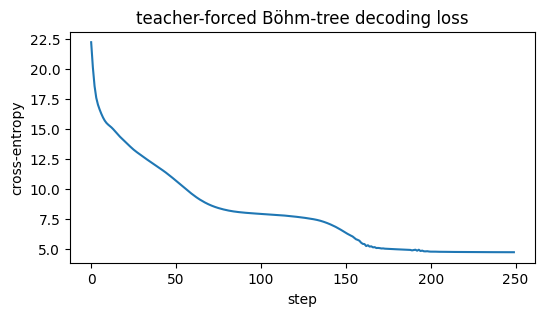

In [12]:
parameters = [*gamma_core.parameters(), *delta_core.parameters(),
              *root.parameters()]
for module in constants.values():
    parameters += list(module.parameters())
optimizer = torch.optim.Adam(parameters, lr=3e-3)

losses = []
for step in range(250):
    optimizer.zero_grad()
    loss = 0
    for nmap, addresses, labels in data:
        logits = answer(nmap, root, addresses)
        loss = loss + torch.nn.functional.cross_entropy(logits, labels)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

import matplotlib.pyplot as plt
plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.xlabel("step"), plt.ylabel("cross-entropy")
plt.title("teacher-forced Böhm-tree decoding loss")
plt.show()

## Decoding

One query per hole, leftmost-outermost, until the tree is complete: the
number of queries is the size of the normal form and the depth of the
queries is its depth — the loop below halts iff the decoded tree does.

In [13]:
def decode(nmap, root, max_nodes=25):
    holes, nodes = [()], {}
    while holes and len(nodes) < max_nodes:
        address = holes.pop(0)
        if len(address) >= L - 1:  # deeper queries do not fit the stack
            nodes[address] = None
            continue
        with torch.no_grad():
            logits = answer(nmap, root, [address])
        nodes[address] = classes[int(logits[0].argmax())]
        holes += [address + (i, ) for i in range(nodes[address][2])]
    return nodes


def tree_to_nodes(tree):
    return {address: node_class(n)
            for address, n in tree_addresses(tree)}


def value_of(nodes):
    """The numeral decoded, i.e. its number of successor nodes."""
    return sum(node is not None and node[1:] == (0, 1)
               for node in nodes.values())


for k in ks:
    decoded = decode(nmaps[k], root)
    outcome = "==" if decoded == tree_to_nodes(targets[k]) else "!="
    print(f"p(church({k})) decoded {outcome} church({a_true * k + b_true})")

exact = sum(decode(nmap, root) == tree_to_nodes(tree)
            for nmap, tree in random_nmaps)
print(f"random linear terms decoded exactly: {exact}/{len(random_nmaps)}")

p(church(1)) decoded == church(3)


p(church(2)) decoded == church(5)


p(church(3)) decoded == church(7)
random linear terms decoded exactly: 4/6


## Guessing the constants

The values of `a` and `b` are determined by the input-output behaviour:
reading the decoded values of `p(1)` and `p(2)` off the Böhm trees and
solving the linear system recovers them — the constants were never observed
directly, only through the execution of the map.

In [14]:
v1 = value_of(decode(nmaps[1], root))
v2 = value_of(decode(nmaps[2], root))
a_hat, b_hat = v2 - v1, 2 * v1 - v2
print(f"inferred a = {a_hat} (true {a_true}), b = {b_hat} (true {b_true})")

inferred a = 2 (true 2), b = 1 (true 1)


In [15]:
# Two honest negatives for this pilot. First, a held-out input:
k = 4
nmap4 = to_networks(
    church(k).to_map() >> p.to_map(), gamma_core, delta_core, constants)
decoded = value_of(decode(nmap4, root))
print(f"held-out p(church(4)): decoded value {decoded}"
      f" (true {a_true * k + b_true})")

# Second, querying a constant box outside any term context:
for name, value in [("a", a_true), ("b", b_true)]:
    nmap_c = to_networks(
        o(name).to_map(), gamma_core, delta_core, constants)
    print(f"constant {name} decoded in isolation:"
          f" value {value_of(decode(nmap_c, root))} (true {value})")

held-out p(church(4)): decoded value 15 (true 9)
constant a decoded in isolation: value 0 (true 2)
constant b decoded in isolation: value 0 (true 1)


## Where to go from here

On the trained maps, differentiable message passing normalizes: the Böhm
trees of the training maps decode (near-)exactly and the unknown constants
are recovered exactly from input-output pairs alone. The two negatives delimit what this
pilot does *not* do: the token language the networks invent is tied to the
graphs it was trained on, so a held-out input or a constant queried outside
any context do not yet decode — generalization needs a richer dataset
(more polynomials, curriculum over term sizes), hard routing at decode time,
and a consistency objective making the token language context-free.

Everything is generic: `to_networks` turns *any* almost-linear term into a
trainable token machine, `pass_messages` runs the execution formula over
arbitrary messages, and the same three shared networks transfer across all
term graphs — string diagrams as neural architectures, with the geometry of
interaction as their operational semantics.